<a href="https://colab.research.google.com/github/harini-3005/Oasis-Infobyte-task-8/blob/main/task8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving apps.csv to apps (1).csv
   Unnamed: 0                                                App  \
0           0     Photo Editor & Candy Camera & Grid & ScrapBook   
1           1                                Coloring book moana   
2           2  U Launcher Lite – FREE Live Cool Themes, Hide ...   
3           3                              Sketch - Draw & Paint   
4           4              Pixel Draw - Number Art Coloring Book   

         Category  Rating  Reviews  Size     Installs  Type Price  \
0  ART_AND_DESIGN     4.1      159  19.0      10,000+  Free     0   
1  ART_AND_DESIGN     3.9      967  14.0     500,000+  Free     0   
2  ART_AND_DESIGN     4.7    87510   8.7   5,000,000+  Free     0   
3  ART_AND_DESIGN     4.5   215644  25.0  50,000,000+  Free     0   
4  ART_AND_DESIGN     4.3      967   2.8     100,000+  Free     0   

  Content Rating                     Genres      Last Updated  \
0       Everyone               Art & Design   January 7, 2018   
1       Everyo

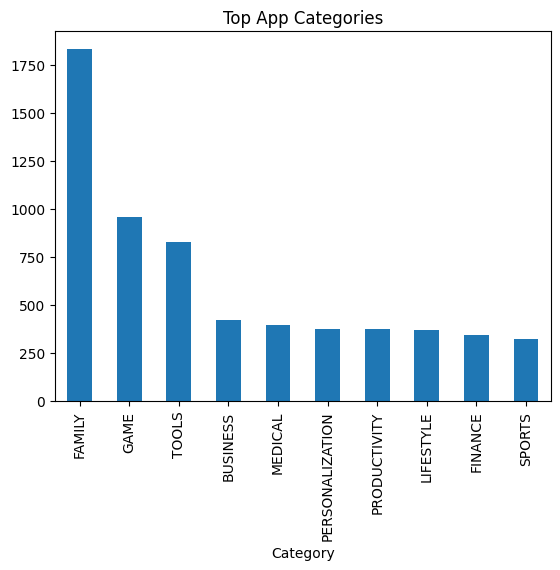

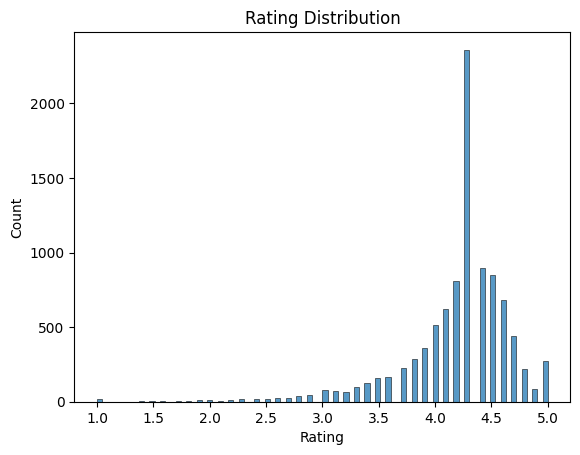

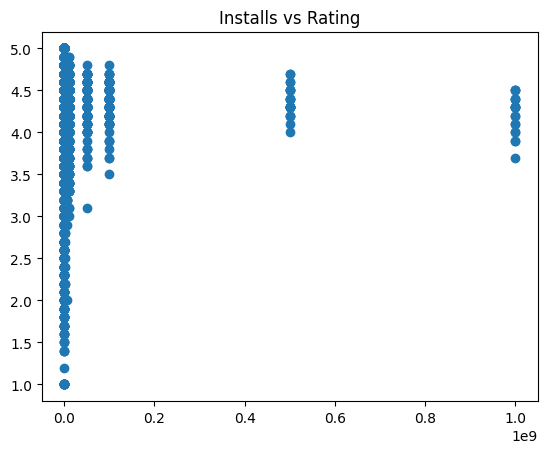

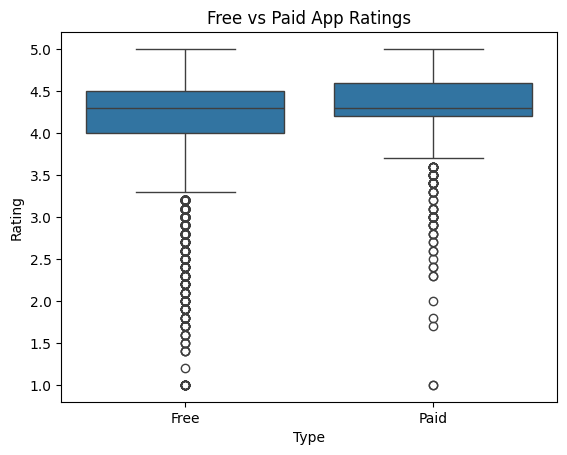

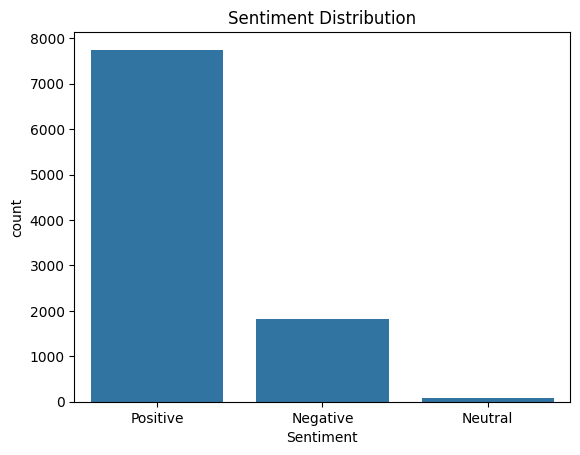

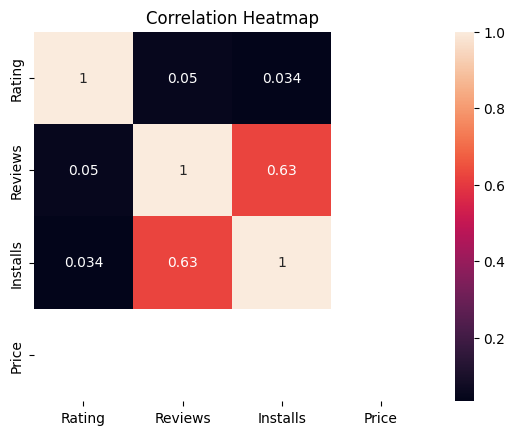


Google Play Store Analysis Completed!


In [ ]:
# =====================================
# GOOGLE PLAY STORE DATA ANALYSIS
# =====================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Upload Dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

# 3. Explore Dataset
print(df.head())
print(df.info())
print(df.isnull().sum())

# =====================================
# 🧹 DATA CLEANING
# =====================================

# Drop duplicates
df.drop_duplicates(inplace=True)

# Convert Reviews to numeric
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# Clean Installs
df['Installs'] = df['Installs'].str.replace('[+,]', '', regex=True)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# Clean Price
df['Price'] = df['Price'].str.replace('$', '', regex=True)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Convert Rating numeric
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# Fill missing
df.fillna(df.median(numeric_only=True), inplace=True)

# =====================================
# 📊 CATEGORY ANALYSIS
# =====================================

plt.figure()
df['Category'].value_counts().head(10).plot(kind='bar')
plt.title("Top App Categories")
plt.show()

# =====================================
# ⭐ RATING DISTRIBUTION
# =====================================

plt.figure()
sns.histplot(df['Rating'])
plt.title("Rating Distribution")
plt.show()

# =====================================
# 📈 INSTALLS VS RATING
# =====================================

plt.figure()
plt.scatter(df['Installs'], df['Rating'])
plt.title("Installs vs Rating")
plt.show()

# =====================================
# 💰 PRICE ANALYSIS
# =====================================

plt.figure()
sns.boxplot(x=df['Type'], y=df['Rating'])
plt.title("Free vs Paid App Ratings")
plt.show()

# =====================================
# 😊 SENTIMENT APPROXIMATION
# =====================================

def sentiment(r):
    if r >= 4:
        return "Positive"
    elif r == 3:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['Rating'].apply(sentiment)

plt.figure()
sns.countplot(x=df['Sentiment'])
plt.title("Sentiment Distribution")
plt.show()

# =====================================
# 🔥 CORRELATION HEATMAP
# =====================================

plt.figure()
sns.heatmap(df[['Rating','Reviews','Installs','Price']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

print("\nGoogle Play Store Analysis Completed!")